1. **Importation des bibliothèque et chargement des données**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("/content/sample_data/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


2. **Analyse des données**

In [5]:
print("Shape :", df.shape)

print(df.dtypes)

df.describe()

df.info()

df.isnull().sum()

df.mean()
df.max()
df.min()
df.median()
df.std()

Shape : (768, 9)
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null   

,0
Pregnancies,3.369578
Glucose,31.972618
BloodPressure,19.355807
SkinThickness,15.952218
Insulin,115.244002
BMI,7.884160
DiabetesPedigreeFunction,0.331329
Age,11.760232
Outcome,0.476951


3. **Nettoyage des données (Data Cleaning)**

In [6]:
cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[cols] = df[cols].replace(0, np.nan)

df.isnull().sum()


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [7]:
#remplacent les valeurs manquantes
for col in cols:
    df[col].fillna(df[col].median(), inplace=True)

df.isnull().sum()

/tmp/ipykernel_13522/1813534831.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


4. **Analyse exploratoire des données (EDA)**

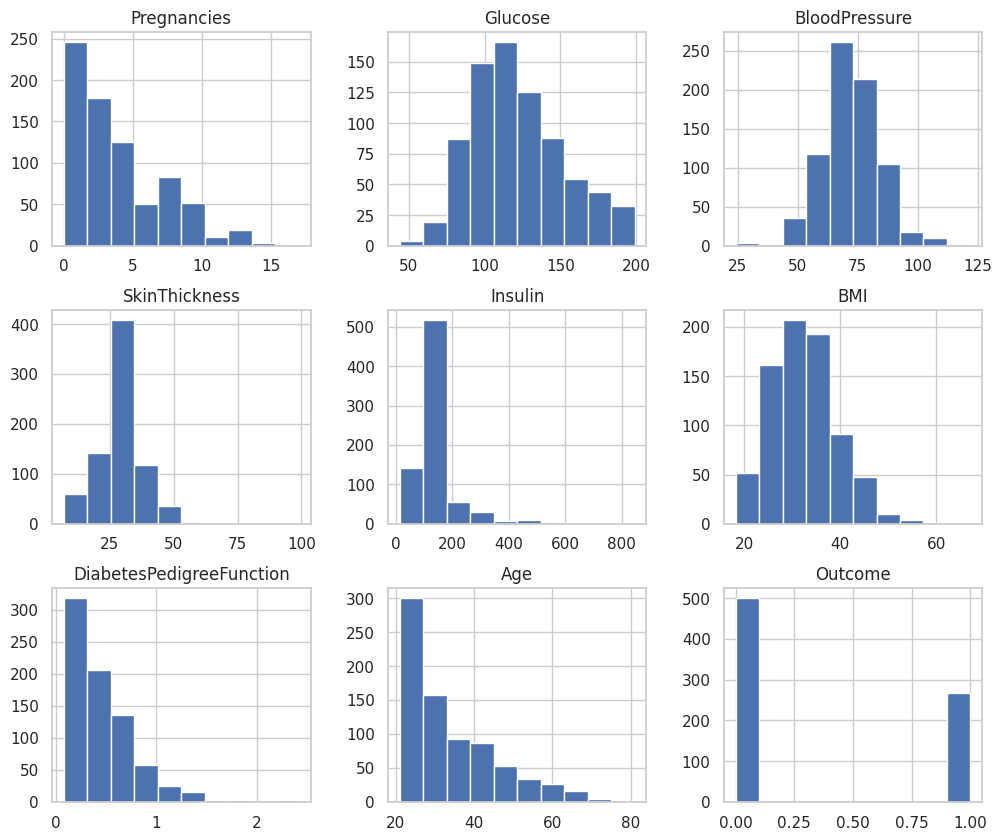

In [8]:
#distrubution des varibales
df.hist(figsize=(12,10))
plt.show()

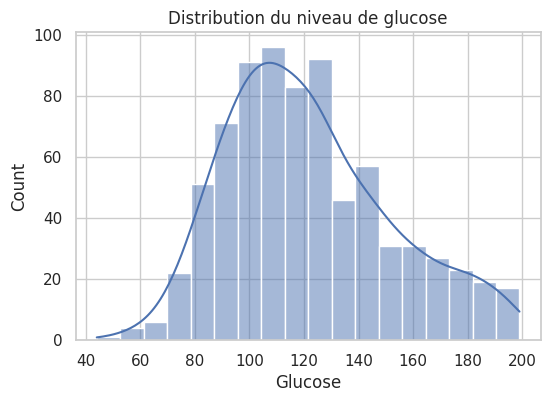

In [9]:
#distrubution de glucose

plt.figure(figsize=(6,4))
sns.histplot(df["Glucose"], kde=True)
plt.title("Distribution du niveau de glucose")
plt.show()

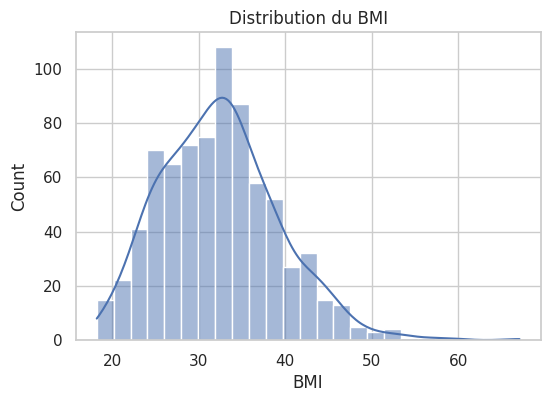

In [10]:
#Distribution du BMI

plt.figure(figsize=(6,4))
sns.histplot(df["BMI"], kde=True)
plt.title("Distribution du BMI")
plt.show()

5. **Segmentation des patients**

In [11]:
#Diabétiques vs Non diabétiques
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


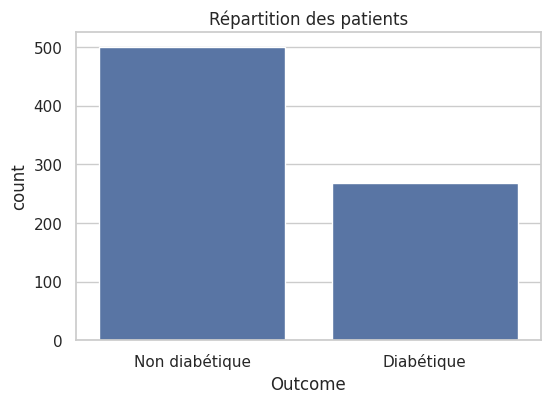

In [12]:
#Vissualisation
plt.figure(figsize=(6,4))
sns.countplot(x="Outcome", data=df)

plt.title("Répartition des patients")
plt.xticks([0,1], ["Non diabétique", "Diabétique"])

plt.show()

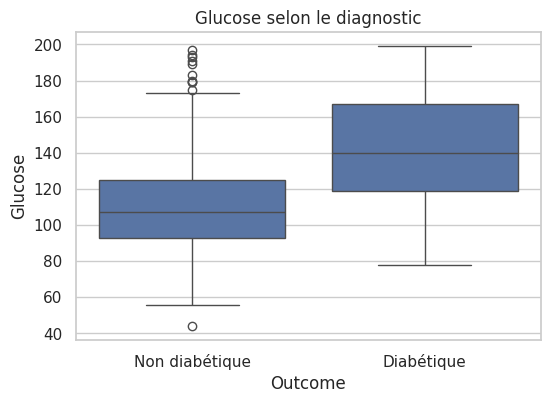

In [13]:
#Comparaison du glucose

plt.figure(figsize=(6,4))

sns.boxplot(x="Outcome", y="Glucose", data=df)

plt.xticks([0,1], ["Non diabétique", "Diabétique"])
plt.title("Glucose selon le diagnostic")

plt.show()

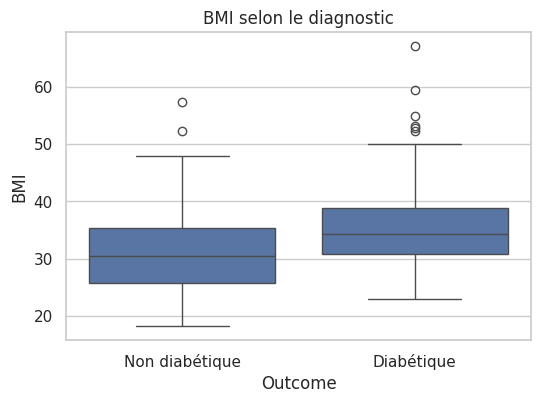

In [14]:
#Comparaison du BMI
plt.figure(figsize=(6,4))

sns.boxplot(x="Outcome", y="BMI", data=df)

plt.xticks([0,1], ["Non diabétique", "Diabétique"])
plt.title("BMI selon le diagnostic")

plt.show()

6. **Analyse de corrélation**

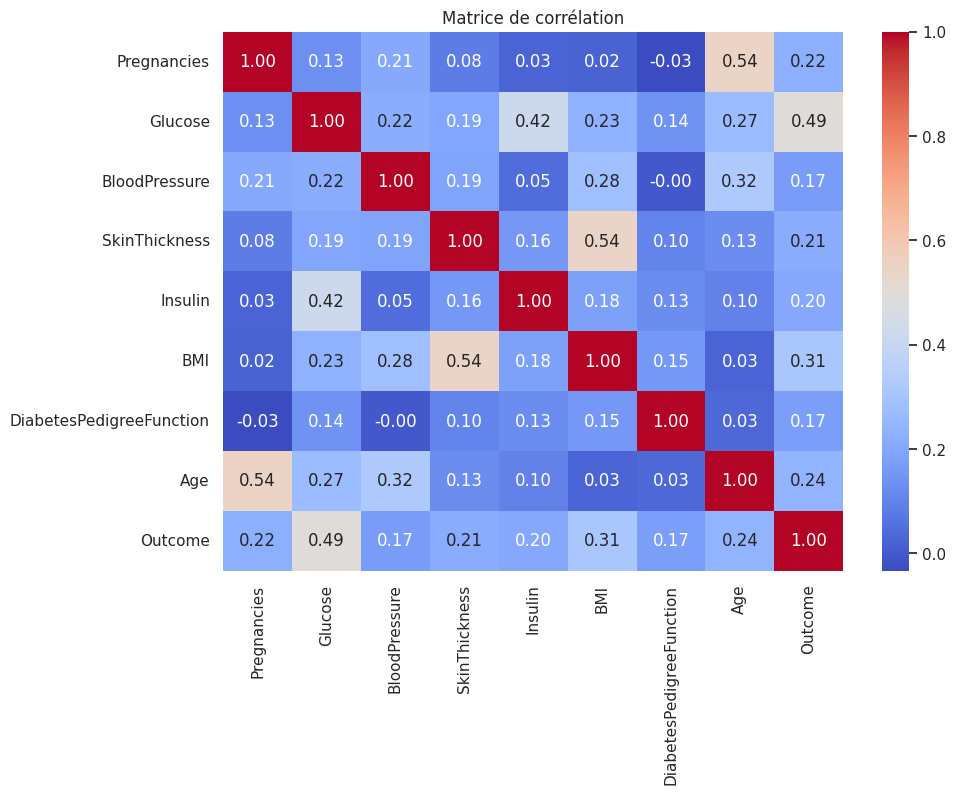

In [15]:
#Voir quelles variables influencent le diabète.

corr = df.corr()

plt.figure(figsize=(10,7))

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Matrice de corrélation")

plt.show()

7. **Corrélation avec le diabète**

In [16]:
corr["Outcome"].sort_values(ascending=False)

,Outcome
Outcome,1.000000
Glucose,0.492782
BMI,0.312038
Age,0.238356
Pregnancies,0.221898
SkinThickness,0.214873
Insulin,0.203790
DiabetesPedigreeFunction,0.173844
BloodPressure,0.165723


**8. Analyse par age**

AgeGroup
age <30      0.215827
30<age<50    0.518519
age >50      0.469136
Name: Outcome, dtype: float64


/tmp/ipykernel_13522/1200669763.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_diabetes = df.groupby("AgeGroup")["Outcome"].mean()


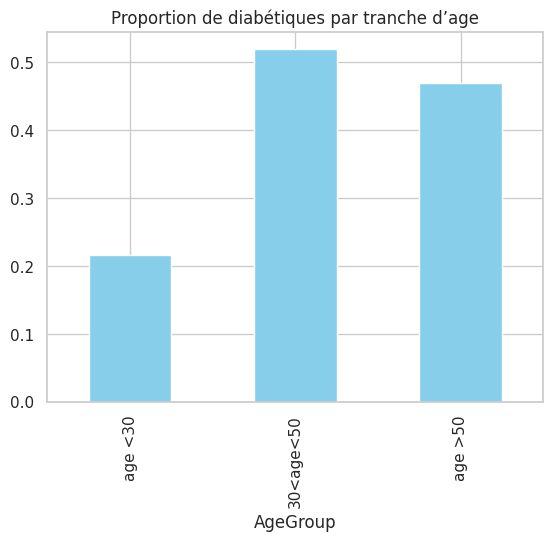

In [17]:
# Segmentation par tranches d’age
df["AgeGroup"] = pd.cut(df["Age"], bins=[0,30,50,100], labels=["age <30","30<age<50","age >50"])

# Proportion de diabétiques par tranche d'age
age_diabetes = df.groupby("AgeGroup")["Outcome"].mean()
print(age_diabetes)

age_diabetes.plot(kind="bar", color="skyblue")
plt.title("Proportion de diabétiques par tranche d’age")
plt.show()

 **9. Analyse du nombre de grossesses**

Pregnancies
0     0.342342
1     0.214815
2     0.184466
3     0.360000
4     0.338235
5     0.368421
6     0.320000
7     0.555556
8     0.578947
9     0.642857
10    0.416667
11    0.636364
12    0.444444
13    0.500000
14    1.000000
15    1.000000
17    1.000000
Name: Outcome, dtype: float64


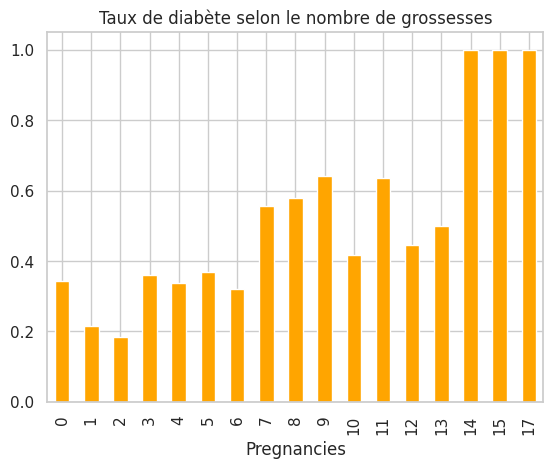

In [18]:
preg_diabetes = df.groupby("Pregnancies")["Outcome"].mean()
print(preg_diabetes)

preg_diabetes.plot(kind="bar", color="orange")
plt.title("Taux de diabète selon le nombre de grossesses")
plt.show()


**10. Formulation des hypothèses**
Pour le Glucose :

H0 : La moyenne du glucose est identique pour les deux groupes.

H1 : La moyenne du glucose est différente.

Pour le BMI :

H0 : La moyenne du BMI est identique pour les deux groupes.

H1 : La moyenne du BMI est différente.


**11. Application du test statistique (t-test)**


In [19]:
from scipy.stats import ttest_ind

diabetique = df[df["Outcome"] == 1]
non_diabetique = df[df["Outcome"] == 0]

# Test t
t_glucose, p_glucose = ttest_ind(diabetique["Glucose"], non_diabetique["Glucose"])
t_bmi, p_bmi = ttest_ind(diabetique["BMI"], non_diabetique["BMI"])

print("p-value Glucose :", p_glucose)
print("p-value BMI :", p_bmi)


p-value Glucose : 3.1287190418423694e-48
p-value BMI : 8.336902677508857e-19


**12. Comparaison des moyennes**

In [ ]:
print("Moyenne Glucose (diabétiques) :", diabetique["Glucose"].mean())
print("Moyenne Glucose (non diabétiques) :", non_diabetique["Glucose"].mean())

print("Moyenne BMI (diabétiques) :", diabetique["BMI"].mean())
print("Moyenne BMI (non diabétiques) :", non_diabetique["BMI"].mean())


Moyenne Glucose (diabétiques) : 142.13059701492537
Moyenne Glucose (non diabétiques) : 110.682
Moyenne BMI (diabétiques) : 35.383582089552235
Moyenne BMI (non diabétiques) : 30.885600000000004


**13. Visualisations avancées**

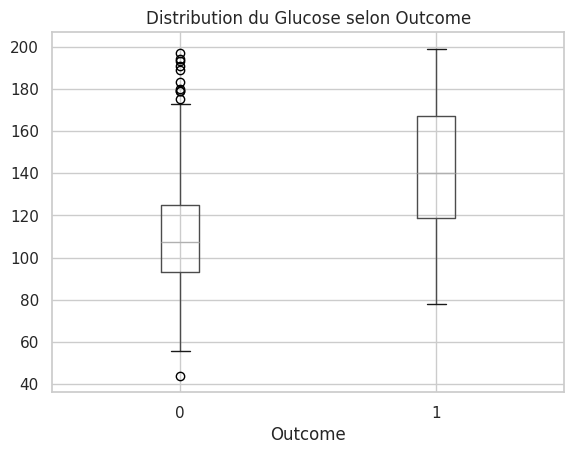

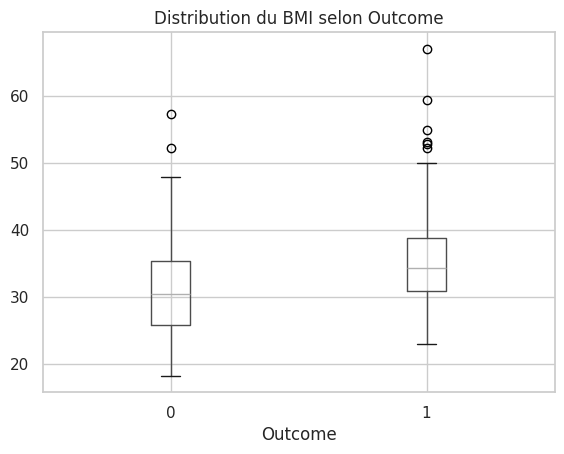

In [ ]:
df.boxplot(column="Glucose", by="Outcome")
plt.title("Distribution du Glucose selon Outcome")
plt.suptitle("")
plt.show()

df.boxplot(column="BMI", by="Outcome")
plt.title("Distribution du BMI selon Outcome")
plt.suptitle("")
plt.show()


**14.Courbe ROC**

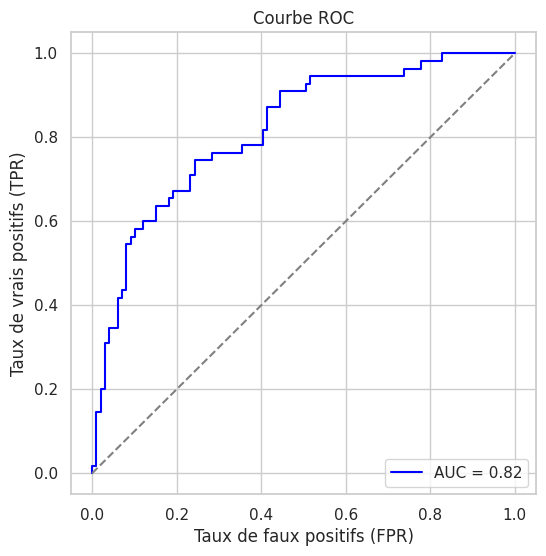

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Variables explicatives et cible
X = df[["Glucose","BMI"]]
y = df["Outcome"]

# Division des données
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Modèle de régression logistique
model = LogisticRegression()
model.fit(X_train,y_train)

# Probabilités prédites
y_prob = model.predict_proba(X_test)[:,1]

# Calcul des points ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Visualisation
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", label="AUC = %0.2f" % roc_auc)
plt.plot([0,1],[0,1],"--",color="gray")
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC")
plt.legend(loc="lower right")
plt.show()


**15.modele de machine learing**

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#  Création d'un dataset simulé
# Glucose et BMI sont générés aléatoirement
np.random.seed(42)
glucose = np.random.randint(70, 200, 200)   # valeurs de glucose
bmi = np.random.uniform(18, 40, 200)        # valeurs de BMI
outcome = (glucose > 120).astype(int)       # règle simple : diabète si glucose > 120

df = pd.DataFrame({"Glucose": glucose, "BMI": bmi, "Outcome": outcome})

# Séparation des variables explicatives et cible
X = df[["Glucose", "BMI"]]
y = df["Outcome"]

# Division en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Création et entraînement du modèle
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Prédictions
y_pred = model.predict(X_test)

#  Affichage des résultats
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Matrice de confusion :\n", confusion_matrix(y_test, y_pred))
print("Rapport de classification :\n", classification_report(y_test, y_pred))
print("Coefficients du modèle :", model.coef_)


Accuracy : 1.0
Matrice de confusion :
 [[16  0]
 [ 0 24]]
Rapport de classification :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        24

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40

Coefficients du modèle : [[ 1.49282767 -0.02039434]]


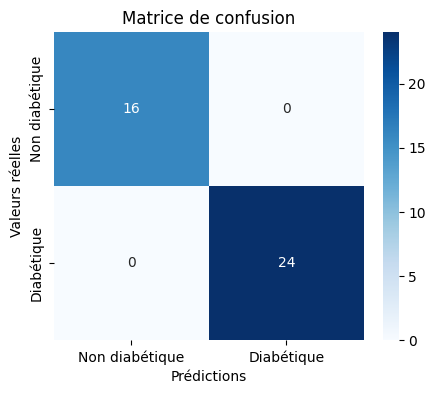

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Non diabétique", "Diabétique"],
            yticklabels=["Non diabétique", "Diabétique"])

plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion")
plt.show()